In [3]:
!pip install --upgrade nbformat


[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [5]:
df = sns.load_dataset("titanic")

In [6]:
print(dir(df))

['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rmatmul__', '__rmod__', '__rmul__', '__ror__', '__

In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
df = df.loc[:, ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", ]]

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 48.9+ KB


In [11]:
df.dropna(axis=0, inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   pclass    714 non-null    int64  
 2   sex       714 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     714 non-null    int64  
 5   parch     714 non-null    int64  
 6   fare      714 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 44.6+ KB


In [13]:
df = pd.get_dummies(df, prefix="")

In [14]:
df.head()

,survived,pclass,age,sibsp,parch,fare,_female,_male
0,0,3,22.0,1,0,7.2500,False,True
1,1,1,38.0,1,0,71.2833,True,False
2,1,3,26.0,0,0,7.9250,True,False
3,1,1,35.0,1,0,53.1000,True,False
4,0,3,35.0,0,0,8.0500,False,True


In [15]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000
mean,0.406162,2.236695,29.699118,0.512605,0.431373,34.694514
std,0.491460,0.838250,14.526497,0.929783,0.853289,52.918930
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.125000,0.000000,0.000000,8.050000
50%,0.000000,2.000000,28.000000,0.000000,0.000000,15.741700
75%,1.000000,3.000000,38.000000,1.000000,1.000000,33.375000
max,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200


In [16]:
fig = px.scatter_matrix(df, dimensions=[*df.columns], color="survived")
fig.update_layout(
    width=900,
    height=800,
    title="Titanic Dataset"
)
fig.show()

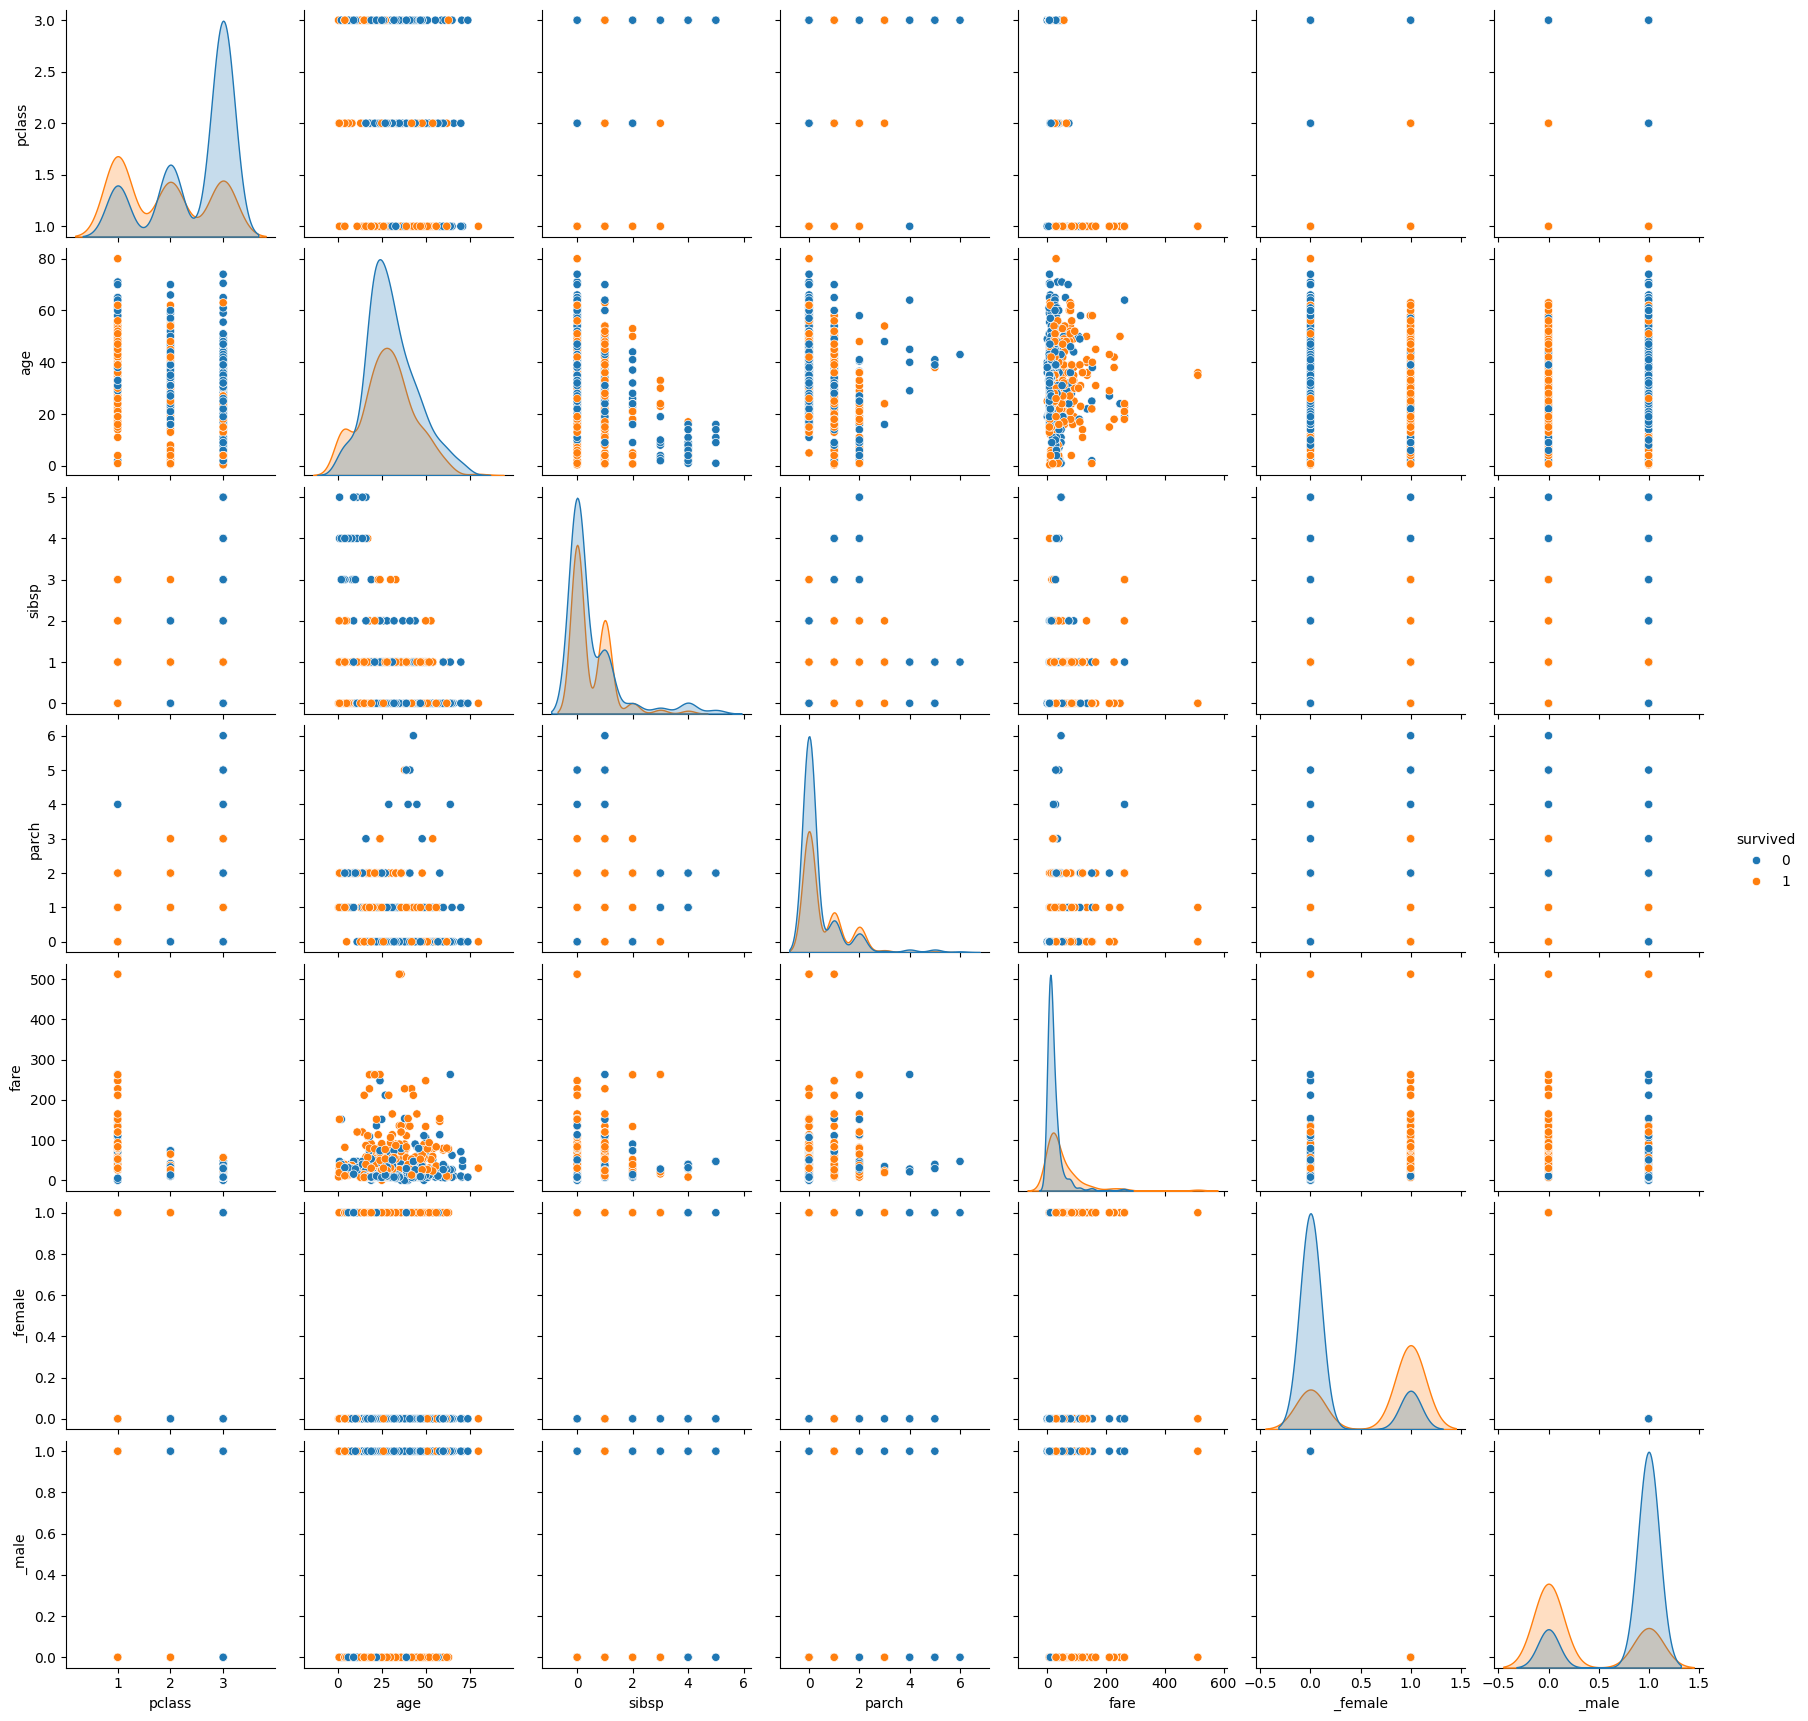

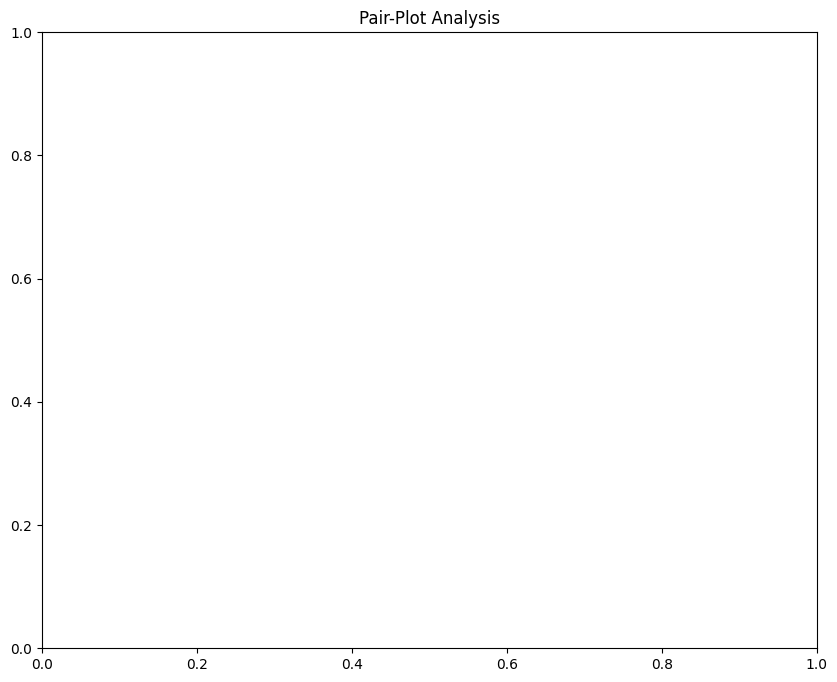

In [17]:
sns.pairplot(data=df, hue="survived")
plt.figure(figsize=(10, 8))
plt.title("Pair-Plot Analysis")
plt.show()

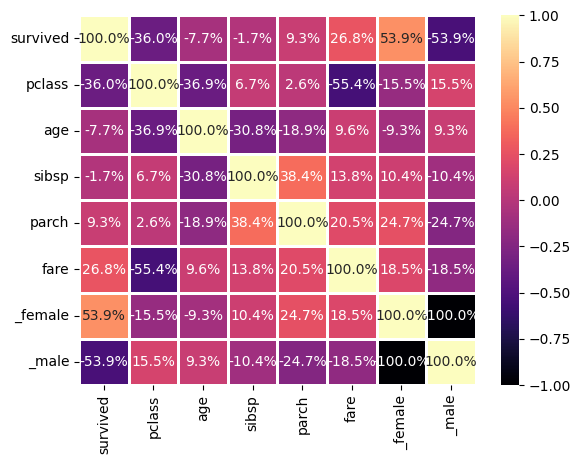

In [18]:
sns.heatmap(df.corr(), annot=True, linewidths=1, fmt=".1%", cmap="magma")
plt.show()

In [19]:
x = df.drop(columns=["survived"], axis=1).values
y = df["survived"].values

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.28, random_state=100)

In [22]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(514, 7) (200, 7) (514,) (200,)


In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(x_train)
scaled_x_test = scaler.transform(x_test)

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [27]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

In [30]:
bagging_model = BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=50, random_state=50)
bagging_model.fit(x_train_scaled, y_train)

BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=50,
                  random_state=50)

In [32]:
bagging_model.score(x_train_scaled, y_train)

0.9474708171206225

In [31]:
bagging_model.score(x_test_scaled, y_test)

0.805

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [35]:
y_pred = bagging_model.predict(x_test_scaled)

In [36]:
accuracy = accuracy_score(y_test, y_pred)

In [37]:
conM = confusion_matrix(y_test, y_pred)

In [38]:
conM

array([[108,  18],
       [ 21,  53]], dtype=int64)

Text(95.72222222222221, 0.5, 'True Values')

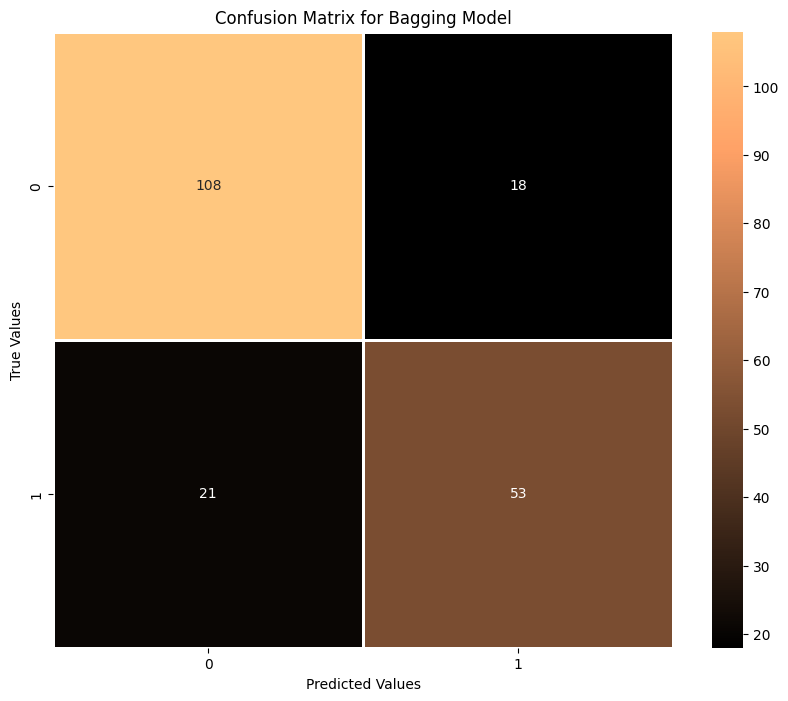

In [40]:
plt.figure(figsize=(10, 8))
sns.heatmap(conM, annot=True, linewidths=1, fmt="d", cmap="copper")
plt.title("Confusion Matrix for Bagging Model")
plt.xlabel("Predicted Values")
plt.ylabel("True Values")

In [41]:
cr = classification_report(y_test, y_pred)
print(f"{cr}")

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       126
           1       0.75      0.72      0.73        74

    accuracy                           0.81       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.80      0.81      0.80       200

